<a href="https://colab.research.google.com/github/isismeira/natural_language_processing/blob/main/topic_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic Modeling

## Pré-processamento

In [76]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [77]:
cd drive/MyDrive/

[Errno 2] No such file or directory: 'drive/MyDrive/'
/content/drive/MyDrive


In [78]:
import spacy
spacy.load('en_core_web_sm')
from spacy.lang.en import English
parser = English()

def tokenize(text):
  lda_tokens = [] # LDA é um algoritmo para modelagem de topicos
  tokens = parser(text)
  for token in tokens:
    if token.text.isspace():
      continue
    elif token.like_url:
      continue
    elif token.text.startswith('@'):
      continue
    else:
      lda_tokens.append(token.lower_)
  return lda_tokens

In [79]:
import nltk
nltk.download('wordnet')
from nltk.corpus import wordnet as wn
def get_lemma(word):
  lemma = wn.morphy(word)
  if lemma is None:
    return word
  else:
    return lemma

from nltk.stem.wordnet import WordNetLemmatizer
def get_lemma2(word):
  return WordNetLemmatizer().lemmatize(word)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [80]:
nltk.download('stopwords')
en_stop = set(nltk.corpus.stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [81]:
import re

Subsitiuir qualquer forma de mencionar o covid por "covid"

In [82]:
def prepare_text_for_lda(text):
  tokens = tokenize(text)
  tokens = [token for token in tokens if len(token) > 4]
  tokens = [token for token in tokens if token not in en_stop]
  tokens = [get_lemma(token) for token in tokens]
  tokens = [re.sub(r'\bcovid[\w-]*\b', r'covid', token) for token in tokens]
  return tokens

Como aqui o foco é a modelagem de tópicos, interessa apenas o texto do tweet

In [83]:
import pandas as pd
train_df = pd.read_csv('corona_tweets_nlp/Corona_NLP_train.csv', encoding='ISO-8859-1', parse_dates=['TweetAt'])[['OriginalTweet']]
test_df = pd.read_csv('corona_tweets_nlp/Corona_NLP_test.csv', encoding='ISO-8859-1', parse_dates=['TweetAt'])[['OriginalTweet']]

/tmp/ipython-input-83-3951170862.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train_df = pd.read_csv('corona_tweets_nlp/Corona_NLP_train.csv', encoding='ISO-8859-1', parse_dates=['TweetAt'])[['OriginalTweet']]


In [84]:
train_df.head()

,OriginalTweet
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/iFz9FAn2Pa and https://t.co/xX6ghGFzCC and https://t.co/I2NlzdxNo8
1,advice Talk to your neighbours family to exchange phone numbers create contact list with phone numbers of neighbours schools employer chemist GP set up online shopping accounts if poss adequate su...
2,"Coronavirus Australia: Woolworths to give elderly, disabled dedicated shopping hours amid COVID-19 outbreak https://t.co/bInCA9Vp8P"
3,"My food stock is not the only one which is empty...\r\r\n\r\r\nPLEASE, don't panic, THERE WILL BE ENOUGH FOOD FOR EVERYONE if you do not take more than you need. \r\r\nStay calm, stay safe.\r\r\n\..."
4,"Me, ready to go at supermarket during the #COVID19 outbreak.\r\r\n\r\r\nNot because I'm paranoid, but because my food stock is litteraly empty. The #coronavirus is a serious thing, but please, don..."


In [85]:
train_df.shape

(41157, 1)

In [86]:
train_data = []
i = 0
while i < train_df.shape[0]:
  line = train_df.iloc[i]['OriginalTweet']
  tokens = prepare_text_for_lda(line)
  if tokens:
    train_data.append(tokens)
  i += 1

In [87]:
test_data = []
i = 0
while i < test_df.shape[0]:
  line = test_df.iloc[i]['OriginalTweet']
  tokens = prepare_text_for_lda(line)
  if tokens:
    test_data.append(tokens)
  i += 1

In [88]:
!pip install gensim

In [89]:
from gensim import corpora
all_data = train_data + test_data
dictionary = corpora.Dictionary(all_data)
corpus =[dictionary.doc2bow(token, allow_update=True) for token in train_data]

In [90]:
print(dictionary)

Dictionary<39428 unique tokens: ['account', 'adequate', 'advice', 'chemist', 'contact']...>


In [91]:
import gensim
NUM_TOPICS = 5
ldamodel = gensim.models.ldamodel.LdaModel(corpus=corpus, id2word = dictionary, num_topics = NUM_TOPICS, random_state=42)
topics = ldamodel.print_topics(num_words=10)
for topic in topics:
  print(topic)

(0, '0.043*"covid" + 0.022*"supermarket" + 0.016*"online" + 0.016*"shopping" + 0.011*"coronavirus" + 0.008*"sanitizer" + 0.008*"people" + 0.007*"delivery" + 0.006*"customer" + 0.006*"social"')
(1, '0.064*"consumer" + 0.051*"covid" + 0.017*"coronavirus" + 0.014*"online" + 0.012*"impact" + 0.012*"change" + 0.012*"pandemic" + 0.010*"business" + 0.009*"shopping" + 0.008*"crisis"')
(2, '0.024*"covid" + 0.020*"supermarket" + 0.019*"coronavirus" + 0.014*"buying" + 0.014*"panic" + 0.012*"people" + 0.011*"supply" + 0.006*"demand" + 0.006*"chain" + 0.006*"lockdown"')
(3, '0.074*"price" + 0.052*"covid" + 0.038*"coronavirus" + 0.014*"demand" + 0.013*"pandemic" + 0.009*"market" + 0.009*"increase" + 0.008*"sanitizer" + 0.006*"people" + 0.006*"supply"')
(4, '0.046*"store" + 0.044*"grocery" + 0.043*"coronavirus" + 0.041*"covid" + 0.018*"worker" + 0.017*"supermarket" + 0.013*"people" + 0.013*"sanitizer" + 0.011*"socialdistancing" + 0.008*"going"')


In [92]:
for topic in topics:
  print(topic)

(0, '0.043*"covid" + 0.022*"supermarket" + 0.016*"online" + 0.016*"shopping" + 0.011*"coronavirus" + 0.008*"sanitizer" + 0.008*"people" + 0.007*"delivery" + 0.006*"customer" + 0.006*"social"')
(1, '0.064*"consumer" + 0.051*"covid" + 0.017*"coronavirus" + 0.014*"online" + 0.012*"impact" + 0.012*"change" + 0.012*"pandemic" + 0.010*"business" + 0.009*"shopping" + 0.008*"crisis"')
(2, '0.024*"covid" + 0.020*"supermarket" + 0.019*"coronavirus" + 0.014*"buying" + 0.014*"panic" + 0.012*"people" + 0.011*"supply" + 0.006*"demand" + 0.006*"chain" + 0.006*"lockdown"')
(3, '0.074*"price" + 0.052*"covid" + 0.038*"coronavirus" + 0.014*"demand" + 0.013*"pandemic" + 0.009*"market" + 0.009*"increase" + 0.008*"sanitizer" + 0.006*"people" + 0.006*"supply"')
(4, '0.046*"store" + 0.044*"grocery" + 0.043*"coronavirus" + 0.041*"covid" + 0.018*"worker" + 0.017*"supermarket" + 0.013*"people" + 0.013*"sanitizer" + 0.011*"socialdistancing" + 0.008*"going"')


In [93]:
test_box = [dictionary.doc2bow(token, allow_update=True) for token in test_data]

In [94]:
test_data[0]

['trend',
 'yorkers',
 'encounter',
 'empty',
 'supermarket',
 'shelf',
 'picture',
 'wegmans',
 'brooklyn',
 'online',
 'grocer',
 'foodkick',
 'maxdelivery',
 'coronavirus',
 'fear',
 'shopper',
 'stock']

In [95]:
print(ldamodel.get_document_topics(test_box[0]))

[(0, 0.012520851), (1, 0.16292661), (2, 0.20603302), (3, 0.26158023), (4, 0.35693932)]


In [96]:
def format_topics_sentences(ldamodel, corpus, texts):
  sent_topics_list = []

  for i, row_list in enumerate(ldamodel[corpus]):
    row = row_list[0] if ldamodel.per_word_topics else row_list
    row = sorted(row, key=lambda x: (x[1]), reverse=True)
    for j, (topic_num, prop_topic) in enumerate(row):
      if j == 0:
        wp = ldamodel.show_topic(topic_num)
        topic_keywords = ", ".join([word for word, prop in wp])
        sent_topics_list.append([int(topic_num), round(prop_topic,4), topic_keywords])
      else:
        break
  sent_topics_df = pd.DataFrame(sent_topics_list, columns=['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords'])
  contents = pd.Series(texts)
  sent_topics_df = pd.concat([sent_topics_df, contents], axis=1)
  return(sent_topics_df)

df_topic_sents_keywords = format_topics_sentences(ldamodel, corpus=test_box, texts=test_data)

df_dominant_topic = df_topic_sents_keywords.reset_index()
df_dominant_topic.columns = ['Document_No', 'Dominant_Topic', 'Topic_Perc_Contrib', 'Keywords', 'Text']
df_dominant_topic.head(10)

,Document_No,Dominant_Topic,Topic_Perc_Contrib,Keywords,Text
0,0,4,0.3570,"store, grocery, coronavirus, covid, worker, supermarket, people, sanitizer, socialdistancing, going","[trend, yorkers, encounter, empty, supermarket, shelf, picture, wegmans, brooklyn, online, grocer, foodkick, maxdelivery, coronavirus, fear, shopper, stock]"
1,1,3,0.7564,"price, covid, coronavirus, demand, pandemic, market, increase, sanitizer, people, supply","[could, sanitizer, meyer, turn, amazon, 114.97, purell??!!check, coronavirus, concern, driving, price]"
2,2,4,0.7941,"store, grocery, coronavirus, covid, worker, supermarket, people, sanitizer, socialdistancing, going","[protect, love, coronavirus]"
3,3,3,0.3199,"price, covid, coronavirus, demand, pandemic, market, increase, sanitizer, people, supply","[panic, buying, newyork, anxious, shopper, stock, food&amp;medical, supply, healthcare, worker, become, bigapple, confirm, coronavirus, patient, bloomberg, stage, event, qanon, qanon2018, qanon202..."
4,4,4,0.4889,"store, grocery, coronavirus, covid, worker, supermarket, people, sanitizer, socialdistancing, going","[toiletpaper, dunnypaper, coronavirus, coronavirusaustralia, coronavirusupdate, covid, 9news, corvid19, 7newsmelb, dunnypapergate, costco, everyone, buying, powder, everyone, buying, toilet, paper]"
5,5,4,0.4728,"store, grocery, coronavirus, covid, worker, supermarket, people, sanitizer, socialdistancing, going","[remember, gallon, regular, angeles?prices, going, coronavirus, impact, price]"
6,6,3,0.8069,"price, covid, coronavirus, demand, pandemic, market, increase, sanitizer, people, supply","[voting, coronavirus, sanitizer, supertuesday]"
7,7,3,0.5757,"price, covid, coronavirus, demand, pandemic, market, increase, sanitizer, people, supply","[canât, covid, without, protect, healthworkers, price, surgical, mask, increase, respirator, treble, gown, twice, much""-@drtedros, coronavirus]"
8,8,4,0.8531,"store, grocery, coronavirus, covid, worker, supermarket, people, sanitizer, socialdistancing, going","[twitter, pharmacist, sanitizer, living, exist, mask, everywhere, worry, visit, twenty, pharmacy, looking, bottle, pharmacy, people]"
9,9,2,0.6058,"covid, supermarket, coronavirus, buying, panic, people, supply, demand, chain, lockdown","[anyone, supermarket, normal, night, sight, greet, barmy, whatâs, special, tin, tomato, covid, dublin]"


In [97]:
pd.options.display.max_colwidth = 100

sent_topics_sorteddf_mallet = pd.DataFrame()
sent_topics_outdf_grpd = df_topic_sents_keywords.groupby('Dominant_Topic')

for i, grp in sent_topics_outdf_grpd:
  sent_topics_sorteddf_mallet = pd.concat([sent_topics_sorteddf_mallet,
                                             grp.sort_values(['Perc_Contribution'], ascending=False).head(1)],
                                            axis=0)

sent_topics_sorteddf_mallet.reset_index(drop=True, inplace=True)

sent_topics_sorteddf_mallet.columns = ['Topic_Num', "Topic_Perc_Contrib", "Keywords", "Representative Text"]

sent_topics_sorteddf_mallet.head(10)


,Topic_Num,Topic_Perc_Contrib,Keywords,Representative Text
0,0,0.9547,"covid, supermarket, online, shopping, coronavirus, sanitizer, people, delivery, customer, social","[please, statement, regard, handling, covid, include, measuring, temperature, everyone, entering..."
1,1,0.9330,"consumer, covid, coronavirus, online, impact, change, pandemic, business, shopping, crisis","[information, covid, option, health, right, health, consumer, alliance, healthcare, covid, covid..."
2,2,0.9520,"covid, supermarket, coronavirus, buying, panic, people, supply, demand, chain, lockdown","[budget, stock, potentially, pantry, week, month, longer, please, think, others, afford, stock, ..."
3,3,0.9573,"price, covid, coronavirus, demand, pandemic, market, increase, sanitizer, people, supply","[demand, vegetable, rise, coronavirusoutbreak, price, continue, remain, vendor, expect, demand, ..."
4,4,0.9621,"store, grocery, coronavirus, covid, worker, supermarket, people, sanitizer, socialdistancing, going","[thank, healthcare, worker, firefighter, police, janitor, grocery, store, staff, every, chance, ..."


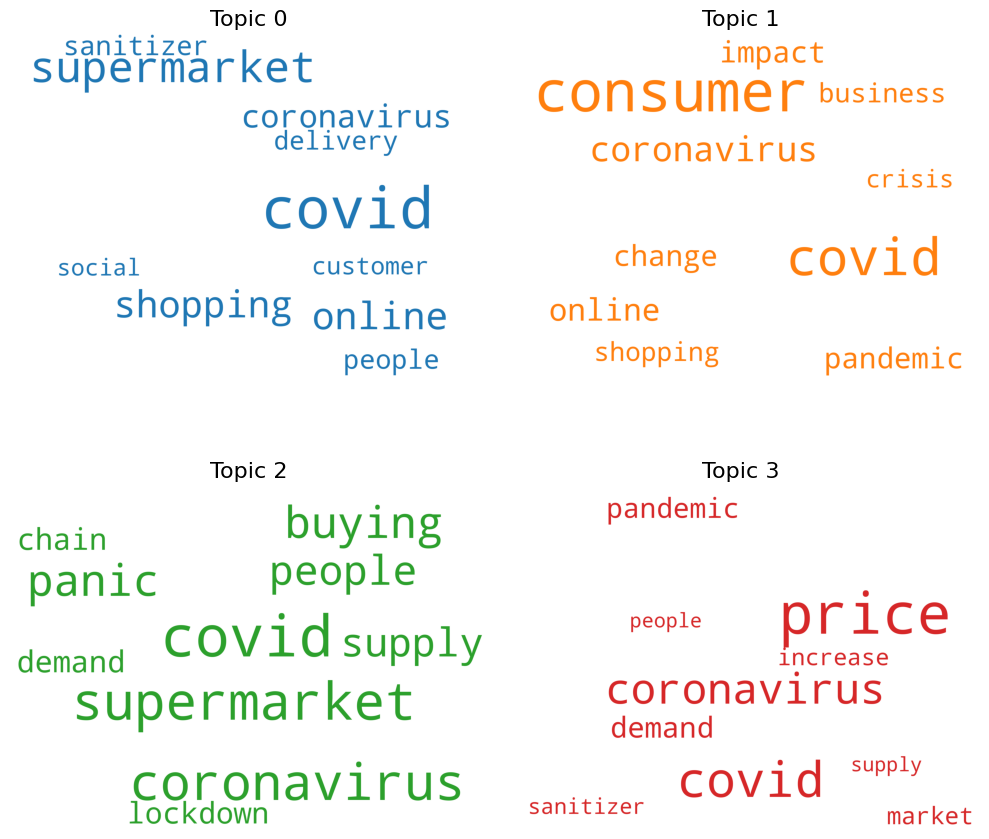

In [98]:
from matplotlib import pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import matplotlib.colors as mcolors

cols = [color for name, color in mcolors.TABLEAU_COLORS.items()]

cloud = WordCloud(stopwords=en_stop,
                  background_color='white',
                  width=2500,
                  height=1800,
                  max_words=10,
                  colormap='tab10',
                  color_func=lambda *args, **kwargs: cols[i],
                  prefer_horizontal=1.0)

topics= ldamodel.show_topics(formatted=False)

fig, axes = plt.subplots(2, 2, figsize=(10,10), sharex=True, sharey=True)
for i, ax in enumerate(axes.flatten()):
  fig.add_subplot(ax)
  topic_words = dict(topics[i][1])
  cloud.generate_from_frequencies(topic_words, max_font_size=300)
  plt.gca().imshow(cloud)
  plt.gca().set_title('Topic ' + str(i), fontdict=dict(size=16))
  plt.gca().axis('off')


fig.subplots_adjust(wspace=0, hspace=0)
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout()
plt.show()

/tmp/ipython-input-99-2388028485.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.loc[df.topic_id==i, 'word'], rotation=30, horizontalalignment= 'right')
/tmp/ipython-input-99-2388028485.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.loc[df.topic_id==i, 'word'], rotation=30, horizontalalignment= 'right')
/tmp/ipython-input-99-2388028485.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.loc[df.topic_id==i, 'word'], rotation=30, horizontalalignment= 'right')
/tmp/ipython-input-99-2388028485.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.loc[df.topic_id=

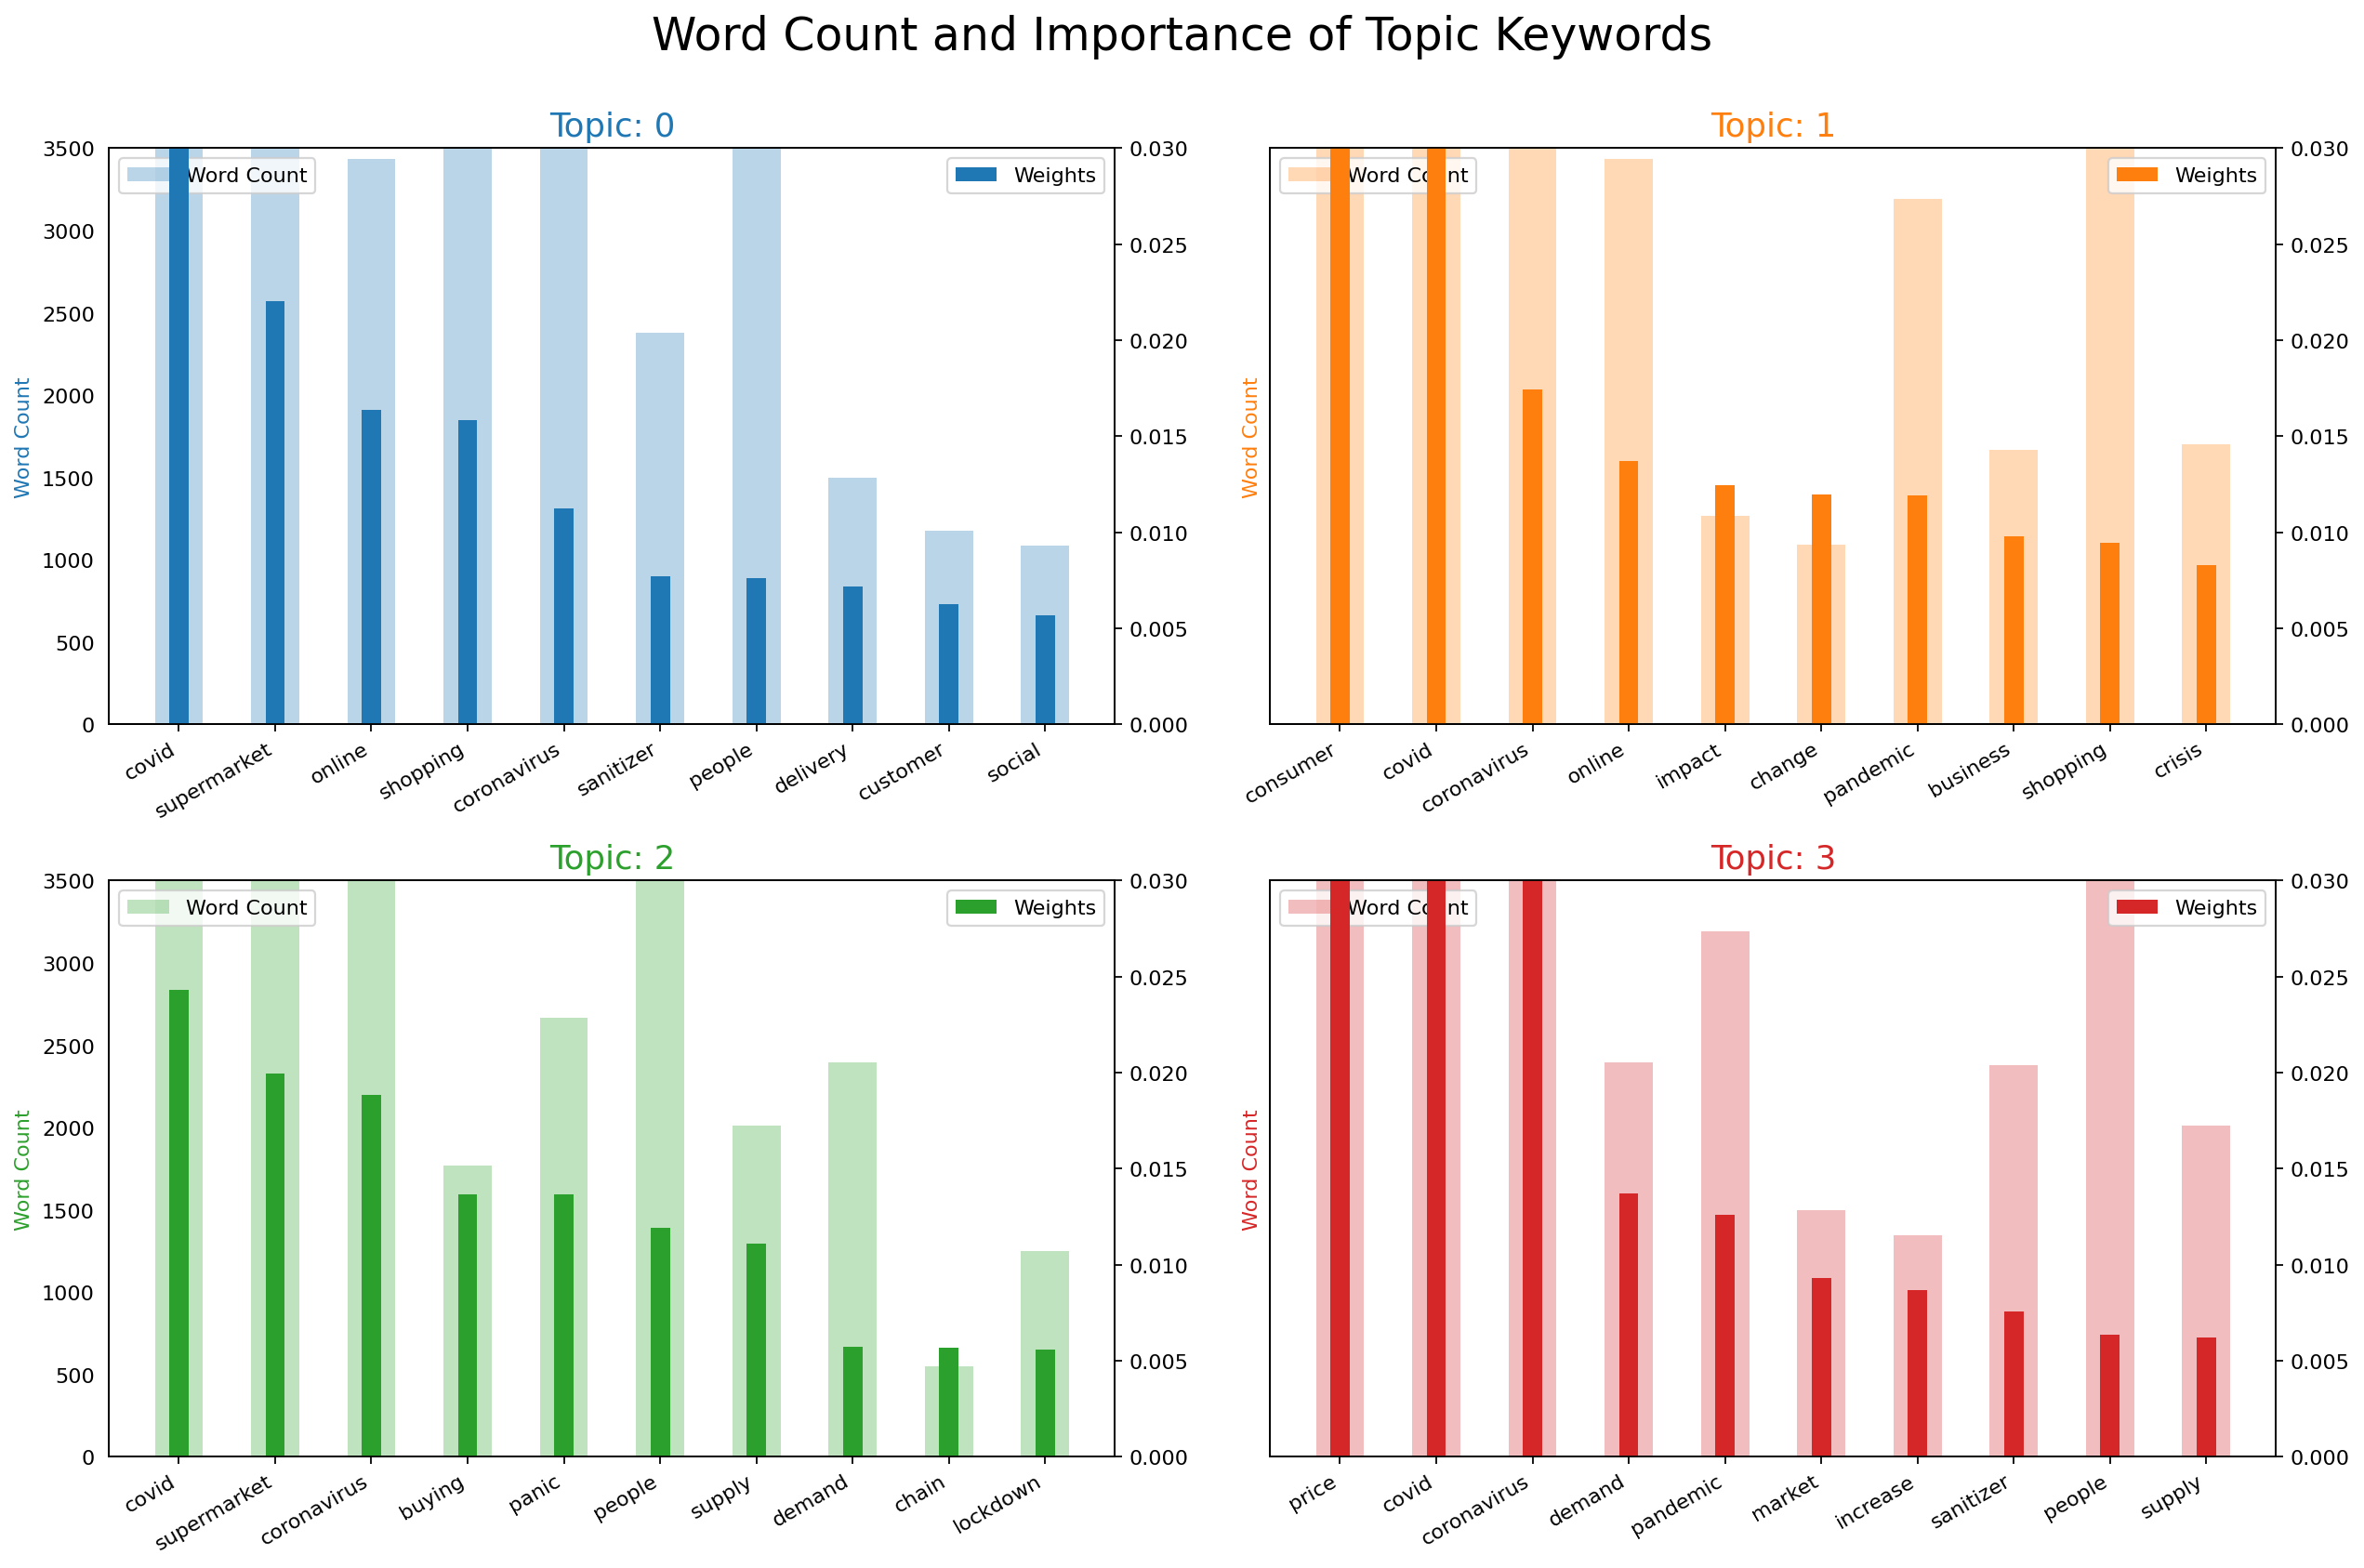

In [99]:
from collections import Counter
topics = ldamodel.show_topics(formatted=False)
data_flat = [w for w_list in train_data for w in w_list]
counter = Counter(data_flat)

out = []
for i, topic in topics:
  for word, weight in topic:
    out.append([word, i, weight, counter[word]])

df = pd.DataFrame(out, columns=['word', 'topic_id', 'importance', 'word_count'])

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey=True, dpi=160)
cols = [color for name, color in mcolors.TABLEAU_COLORS.items()]
for i, ax in enumerate(axes.flatten()):
  ax.bar(x='word', height="word_count", data=df.loc[df.topic_id==i, :], color=cols[i], width=0.5, alpha=0.3, label='Word Count')
  ax_twin = ax.twinx()
  ax_twin.bar(x='word', height="importance", data=df.loc[df.topic_id==i, :], color=cols[i], width=0.2, label='Weights')
  ax.set_ylabel('Word Count', color=cols[i])
  ax_twin.set_ylim(0, 0.030); ax.set_ylim(0, 3500)
  ax.set_title('Topic: ' + str(i), color=cols[i], fontsize=16)
  ax.tick_params(axis='y', left=False)
  ax.set_xticklabels(df.loc[df.topic_id==i, 'word'], rotation=30, horizontalalignment= 'right')
  ax.legend(loc='upper left'); ax_twin.legend(loc='upper right')

fig.tight_layout(w_pad=2)
fig.suptitle('Word Count and Importance of Topic Keywords', fontsize=22, y=1.05)
plt.show()

/tmp/ipython-input-100-1566070806.py:73: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


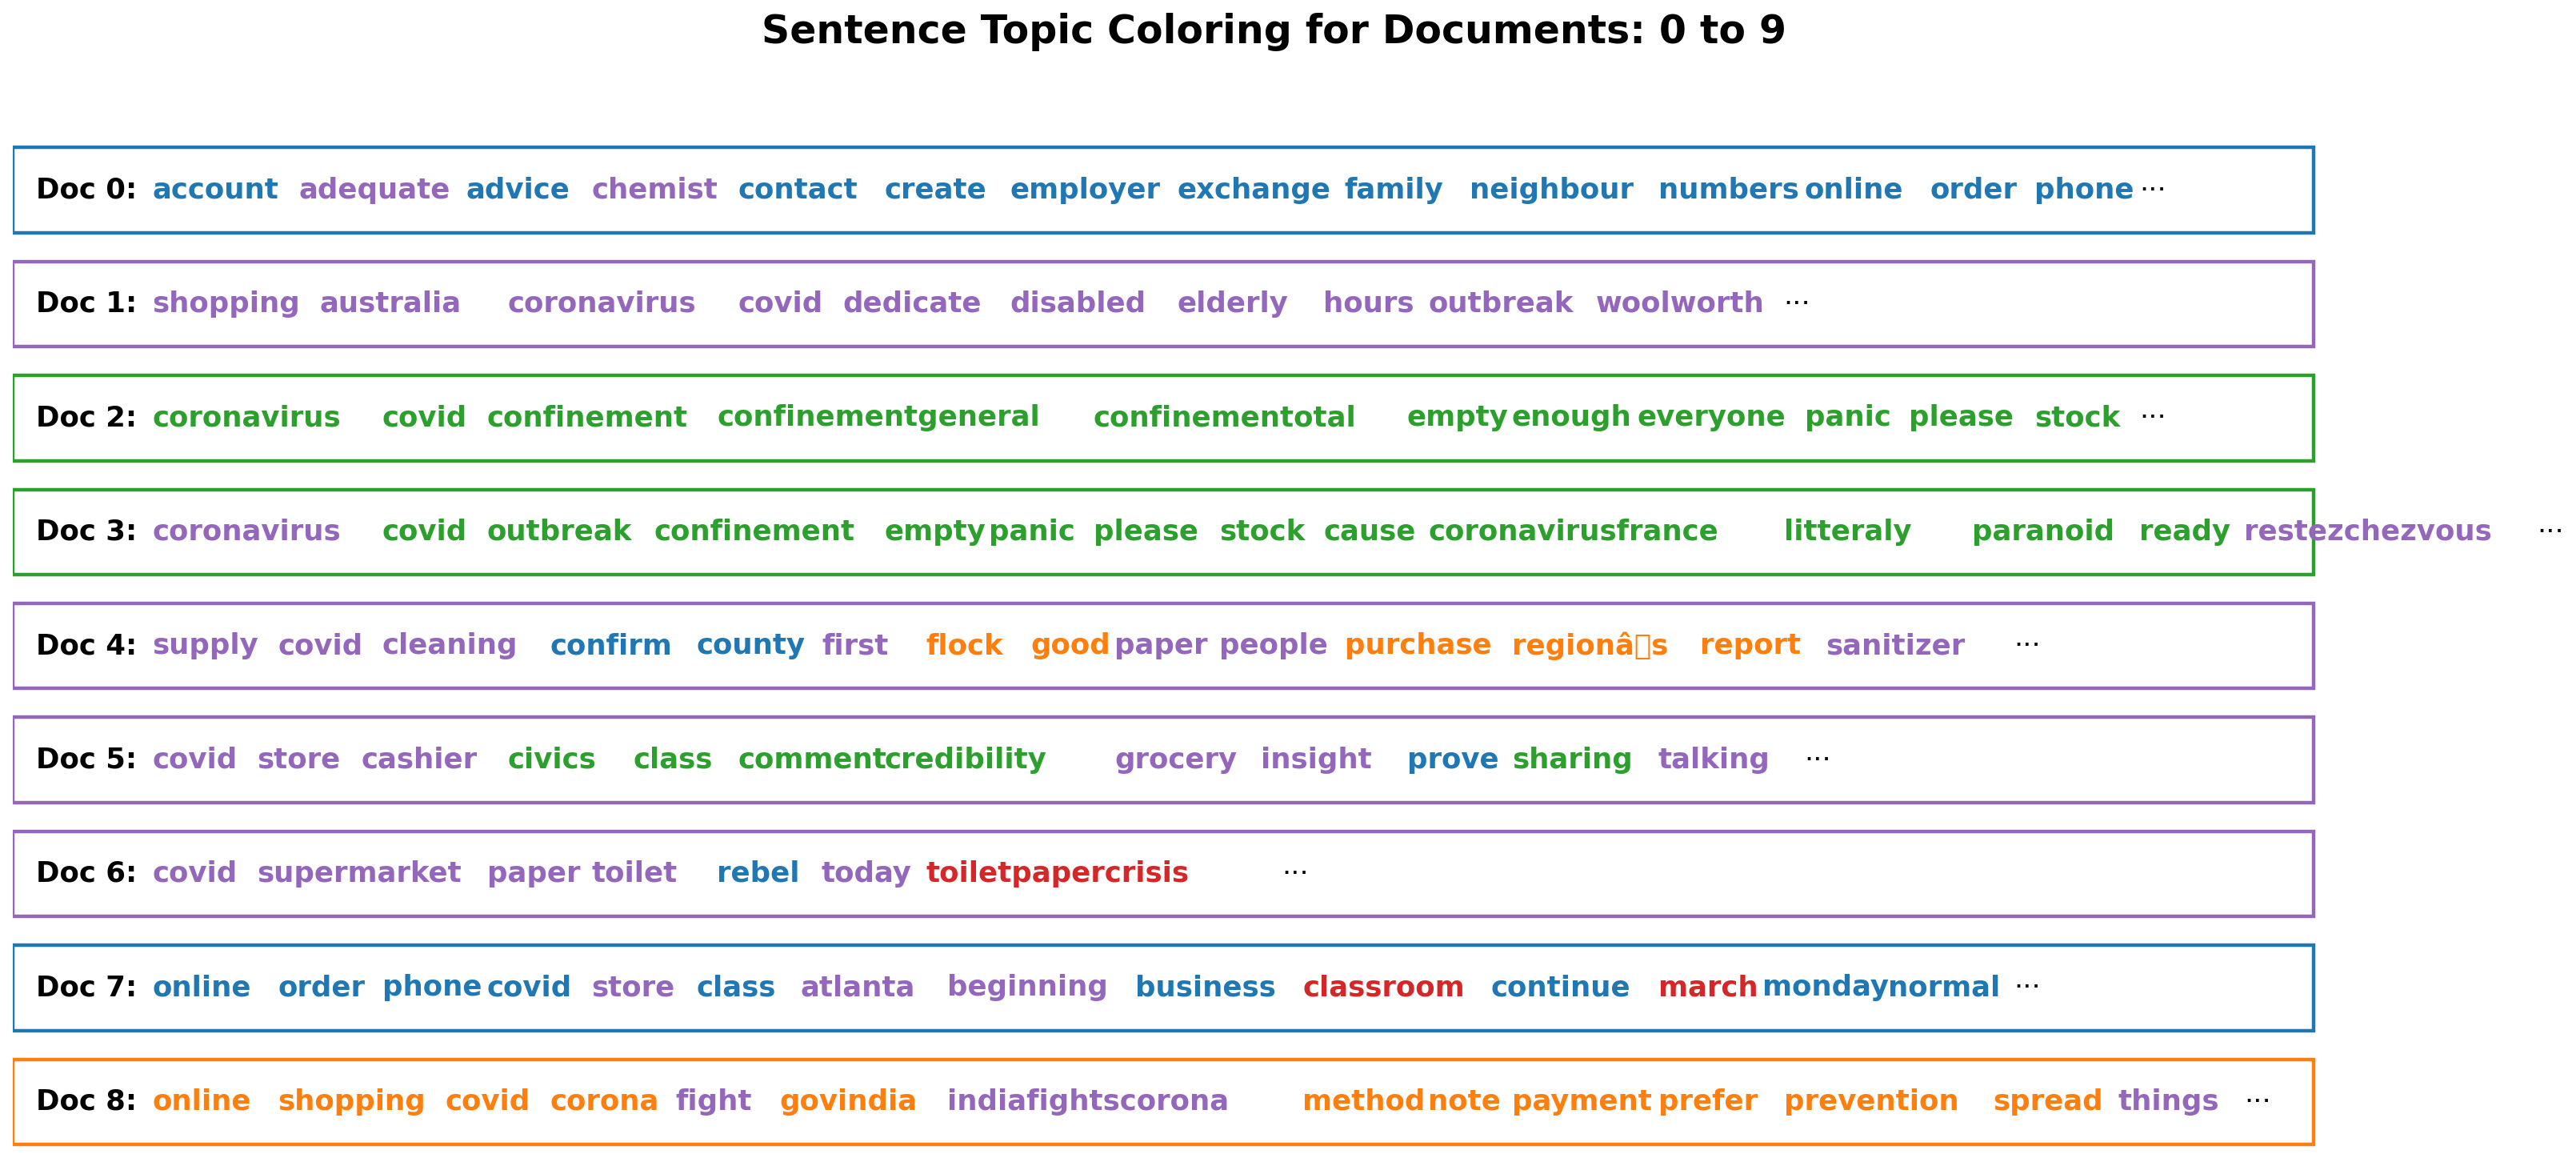

In [100]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import colors as mcolors

def sentences_chart(lda_model, corpus, start=0, end=13):
    """
    Visualiza os documentos com destaque para as palavras e seus tópicos dominantes.

    Parâmetros:
        lda_model: Modelo LDA treinado (gensim.models.LdaModel)
        corpus: Corpus no formato bag-of-words
        start: Índice inicial dos documentos a visualizar
        end: Índice final (não inclusivo)
    """
    subset_corpus = corpus[start:end]
    num_docs = end - start

    # Paleta de cores
    mycolors = list(mcolors.TABLEAU_COLORS.values())

    # Subplots verticais
    fig, axes = plt.subplots(num_docs, 1, figsize=(20, num_docs * 0.95), dpi=160)
    axes = [axes] if num_docs == 1 else axes  # garantir que seja iterável

    axes[0].axis('off')  # eixo do título

    for i, ax in enumerate(axes):
        if i == 0:
            continue  # pula título

        doc_index = start + i - 1
        bow = subset_corpus[i - 1]

        # Obter tópicos por documento e por palavra
        topic_percs, wordid_topics, wordid_phivalues = lda_model.get_document_topics(bow, per_word_topics=True)

        # Lista de tuplas (palavra, tópico dominante)
        word_dominanttopic = [
            (lda_model.id2word[word_id], topic_ids[0])
            for word_id, topic_ids in wordid_topics
            if topic_ids
        ]

        # Nome do documento
        ax.text(0.01, 0.5, f"Doc {doc_index}:", verticalalignment='center',
                fontsize=16, color='black', transform=ax.transAxes, fontweight='bold')

        # Retângulo com cor do tópico mais forte no documento
        dominant_topic = sorted(topic_percs, key=lambda x: x[1], reverse=True)[0][0]
        ax.add_patch(Rectangle((0.0, 0.05), 0.99, 0.90,
                               fill=None, alpha=1,
                               color=mycolors[dominant_topic % len(mycolors)],
                               linewidth=2))

        # Escrever as palavras
        word_pos = 0.06
        for j, (word, topic_id) in enumerate(word_dominanttopic[:14]):
            ax.text(word_pos, 0.5, word,
                    horizontalalignment='left',
                    verticalalignment='center',
                    fontsize=16, color=mycolors[topic_id % len(mycolors)],
                    transform=ax.transAxes, fontweight='bold')
            word_pos += .009 * len(word)

        # Reticências
        ax.text(word_pos, 0.5, '...', fontsize=16, transform=ax.transAxes, color='black')
        ax.axis('off')

    # Título geral
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.suptitle(f'Sentence Topic Coloring for Documents: {start} to {end - 1}',
                 fontsize=22, y=0.95, fontweight='bold')
    plt.tight_layout()
    plt.show()


sentences_chart(lda_model=ldamodel, corpus=corpus, start=0, end=10)

In [101]:
!pip install pyLDAvis

In [102]:
import pyLDAvis.gensim
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(ldamodel, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.167150  0.034053       1        1  27.486621
3      0.073468 -0.211446       2        1  22.026019
0     -0.044036  0.094570       3        1  19.823293
1      0.235097  0.100627       4        1  16.591903
2     -0.097379 -0.017804       5        1  14.072164, topic_info=            Term         Freq        Total Category  logprob  loglift
216        price  8955.000000  8955.000000  Default  30.0000  30.0000
145     consumer  5907.000000  5907.000000  Default  29.0000  29.0000
67       grocery  6642.000000  6642.000000  Default  28.0000  28.0000
59         store  7315.000000  7315.000000  Default  27.0000  27.0000
45   supermarket  6518.000000  6518.000000  Default  26.0000  26.0000
..           ...          ...          ...      ...      ...      ...
199     pandemic   313.279178  3851.283743   Topic5  -5.4914  -0.5481
34        please   233.652373  1331.401531   Topic5  -5.7847   0.2208
196        world   222.774195  1032.294898   Topic5  -5.8324   0.4276
392        local   210.591803  1146.324578   Topic5  -5.8886   0.2666
265       worker   201.352092  3092.094603   Topic5  -5.9335  -0.7706

[403 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
2356      2  0.992779   accelerate
2356      3  0.008786   accelerate
3099      4  0.993552  advertising
3165      5  0.990481       advise
163       1  0.012200       affect
...     ...       ...          ...
569       2  0.281200        would
569       3  0.303221        would
569       4  0.052513        would
569       5  0.034726        would
3465      2  0.993755        write

[877 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 4, 1, 2, 3])

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_colwidth", 200)

In [104]:
sk_data = [" ".join(line) for line in all_data]

sk_train_data = [" ".join(line) for line in train_data]
sk_test_data = [" ".join(line) for line in test_data]
sk_train_data[:5]

['advice neighbour family exchange phone numbers create contact phone numbers neighbour school employer chemist online shopping account adequate supply regular order',
 'coronavirus australia woolworth elderly disabled dedicate shopping hours covid outbreak',
 'stock empty please panic enough everyone covid covid covid coronavirus confinement confinementotal confinementgeneral',
 'ready supermarket covid outbreak paranoid stock litteraly empty coronavirus serious thing please panic cause shortage coronavirusfrance restezchezvous stayathome confinement',
 'regionâ\x92s first confirm covid sullivan county people flock store purchase cleaning supply sanitizer toilet paper good report']

In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer

text = []
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.5, smooth_idf=True).fit(sk_data)
x_train_svd = vectorizer.fit_transform(sk_train_data)
x_test_svd = vectorizer.fit_transform(sk_test_data)

x_train_svd.shape
x_test_svd.shape

(3796, 7628)

In [106]:
from sklearn.decomposition import TruncatedSVD
svd_model = TruncatedSVD(n_components=10, algorithm='randomized', n_iter=100, random_state=122)
svd_model.fit(x_train_svd)
len(svd_model.components_)

10

In [107]:
terms = vectorizer.get_feature_names_out()

for i, comp in enumerate(svd_model.components_):
  terms_comp = zip(terms, comp)
  sorted_terms = sorted(terms_comp, key=lambda x:x[1], reverse=True)[:7]
  print("Topic "+str(i)+": ")
  for t in sorted_terms:
    print(t[0])
    print(" ")

Topic 0: 
vulnerable
 
todayâ
 
panicbuying
 
outlet
 
soapandwater
 
ahahaha
 
remedy
 
Topic 1: 
skype
 
soapandwater
 
zombie
 
pround
 
zionist
 
independent
 
socioeconomic
 
Topic 2: 
deciding
 
indication
 
outlet
 
remedy
 
friedrice
 
study
 
celebrity
 
Topic 3: 
panicbuying
 
vulnerable
 
urself
 
ahahaha
 
coronaupdate
 
pandemicâ
 
wipe
 
Topic 4: 
vulnerable
 
ahahaha
 
unpreparedness
 
wherearethetes
 
panicbuying
 
coronavirususa
 
payrolltax
 
Topic 5: 
todayâ
 
indication
 
remedy
 
outlet
 
vulnerable
 
misbranded
 
indiewrestling
 
Topic 6: 
panicbuying
 
todayâ
 
remedy
 
indication
 
pandemicâ
 
refund
 
urself
 
Topic 7: 
todayâ
 
outlet
 
indication
 
tremendously
 
remedy
 
independent
 
siezed
 
Topic 8: 
panicbuying
 
vulnerable
 
coronavirususa
 
deciding
 
independent
 
pandemicâ
 
refund
 
Topic 9: 
todayâ
 
coronavirususa
 
means
 
indication
 
supermarkety
 
tpapocalypse
 
ironic
 
